# TP3 — Diagramas de relación/influencia entre variables (3.4 / Anexo)

**Investigación de Operaciones II (11.87) — RedBaires S.A.**

La rúbrica pide, dentro de "Modelo de datos y cuantificación", un **diagrama de
relación/influencia entre variables** — distinto del diagrama de eventos de 2.6 (que
muestra el *flujo de control* del simulador) y del IDEF0 de 2.5 (que muestra
*procesos*). Acá el objeto es otro: qué variable determina/influye a cuál, sin importar
el orden temporal de ejecución.

Se arman **dos diagramas** para que cada uno sea legible (el modelo tiene demasiadas
variables para uno solo sin que se vuelva ilegible):

1. **Generación y multiplicador de reenvíos** — cómo los atributos de un nodo y las
   contramedidas VD2/VD3 determinan `ME` y de ahí `HIJOS`.
2. **Clasificación, moderación y costos** — cómo TOX/TEMA determinan FLAG, cómo se
   resuelve la cola de moderación, y cómo se arman las VR finales.

**Regla de la rúbrica a respetar** ("usar variables de referencia anula el punto por
completo"): las VR (`ALCANCE_NOC`, `COSTO`) son siempre **sumidero** — tienen flechas
entrantes, nunca salientes. Se verifica programáticamente al final de cada diagrama.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Ellipse
from matplotlib.path import Path
import matplotlib.font_manager as fm

COLOR = {
    'VD':        '#2E6F9E',   # azul — variable de decision
    'Parametro': '#8A8A8A',   # gris — parametro fijo
    'VA':        '#C9742F',   # naranja — variable aleatoria (sorteo)
    'Derivada':  '#6A4C93',   # violeta — se calcula de otras
    'Estado':    '#1C8C6B',   # verde azulado — variable/recurso de estado
    'VR':        '#B5293E',   # rojo — variable de referencia (resultado, sumidero)
}
LABEL_TIPO = {
    'VD': 'Variable de decisión (VD)', 'Parametro': 'Parámetro',
    'VA': 'Variable aleatoria (VA)', 'Derivada': 'Derivada',
    'Estado': 'Estado / recurso', 'VR': 'Variable de referencia (VR)',
}

def draw_node(ax, node):
    x, y, w, h, label, tipo = node['x'], node['y'], node['w'], node['h'], node['label'], node['tipo']
    color = COLOR[tipo]
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.02,rounding_size=0.08",
                          linewidth=1.4, edgecolor=color, facecolor=color + '22')
    ax.add_patch(box)
    fontweight = 'bold' if tipo == 'VR' else 'normal'
    ax.text(x, y, label, ha='center', va='center', fontsize=8.3, color='#202020',
             fontweight=fontweight, wrap=True)

def draw_edge(ax, nodes_by_id, src, dst, label=None, style='-', color='#555555', curve=0.0,
              waypoints=None, label_frac=0.5, label_offset=(0, 0)):
    a, b = nodes_by_id[src], nodes_by_id[dst]
    if waypoints:
        pts = [(a['x'], a['y'])] + list(waypoints) + [(b['x'], b['y'])]
        codes = [Path.MOVETO] + [Path.LINETO] * (len(pts) - 1)
        path = Path(pts, codes)
        arrow = FancyArrowPatch(path=path, arrowstyle='-|>', mutation_scale=11,
                                 linewidth=1.1, linestyle=style, color=color, zorder=1)
        ax.add_patch(arrow)
        idx = max(0, min(len(pts) - 2, int(round(label_frac * (len(pts) - 1)))))
        mx = (pts[idx][0] + pts[idx + 1][0]) / 2 + label_offset[0]
        my = (pts[idx][1] + pts[idx + 1][1]) / 2 + label_offset[1]
    else:
        arrow = FancyArrowPatch((a['x'], a['y']), (b['x'], b['y']),
                                 connectionstyle=f"arc3,rad={curve}",
                                 arrowstyle='-|>', mutation_scale=11,
                                 linewidth=1.1, linestyle=style, color=color,
                                 shrinkA=22, shrinkB=22, zorder=1)
        ax.add_patch(arrow)
        mx = (a['x'] + b['x']) / 2 + (0 if curve == 0 else curve * 1.4) + label_offset[0]
        my = (a['y'] + b['y']) / 2 + label_offset[1]
    if label:
        ax.text(mx, my, label, ha='center', va='center', fontsize=6.6, color='#444444',
                 style='italic', bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.9),
                 zorder=3)

def check_vr_is_sink(edges, nodes_by_id):
    vr_ids = {nid for nid, n in nodes_by_id.items() if n['tipo'] == 'VR'}
    violaciones = [e for e in edges if e[0] in vr_ids]
    assert not violaciones, f"VR con flecha saliente (invalida el diagrama para la rubrica): {violaciones}"
    print(f"OK: {len(vr_ids)} variable(s) de referencia, todas sumidero (sin salida).")

def render_diagram(nodes, edges, title, out_path, figsize=(11, 7), notes=None):
    nodes_by_id = {n['id']: n for n in nodes}
    check_vr_is_sink([(e['src'], e['dst']) for e in edges], nodes_by_id)
    fig, ax = plt.subplots(figsize=figsize)
    for e in edges:
        draw_edge(ax, nodes_by_id, e['src'], e['dst'], e.get('label'), e.get('style', '-'),
                   curve=e.get('curve', 0.0), waypoints=e.get('wp'),
                   label_frac=e.get('label_frac', 0.5), label_offset=e.get('label_offset', (0, 0)))
    for n in nodes:
        draw_node(ax, n)
    for note in (notes or []):
        ax.text(note['x'], note['y'], note['text'], ha=note.get('ha', 'center'),
                 va=note.get('va', 'center'), fontsize=6.8, style='italic', color='#666666')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=14)
    xs = [n['x'] for n in nodes]; ys = [n['y'] for n in nodes]
    ax.set_xlim(min(xs) - 1.6, max(xs) + 1.6)
    ax.set_ylim(min(ys) - 1.0, max(ys) + 1.2)
    ax.axis('off')
    handles = [mpatches.Patch(facecolor=COLOR[t] + '33', edgecolor=COLOR[t], label=LABEL_TIPO[t])
               for t in ['VD', 'Parametro', 'VA', 'Derivada', 'Estado', 'VR']]
    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.05),
              ncol=3, fontsize=7.5, frameon=False)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print("Guardado:", out_path)


## 1. Generación y multiplicador de reenvíos

OK: 1 variable(s) de referencia, todas sumidero (sin salida).


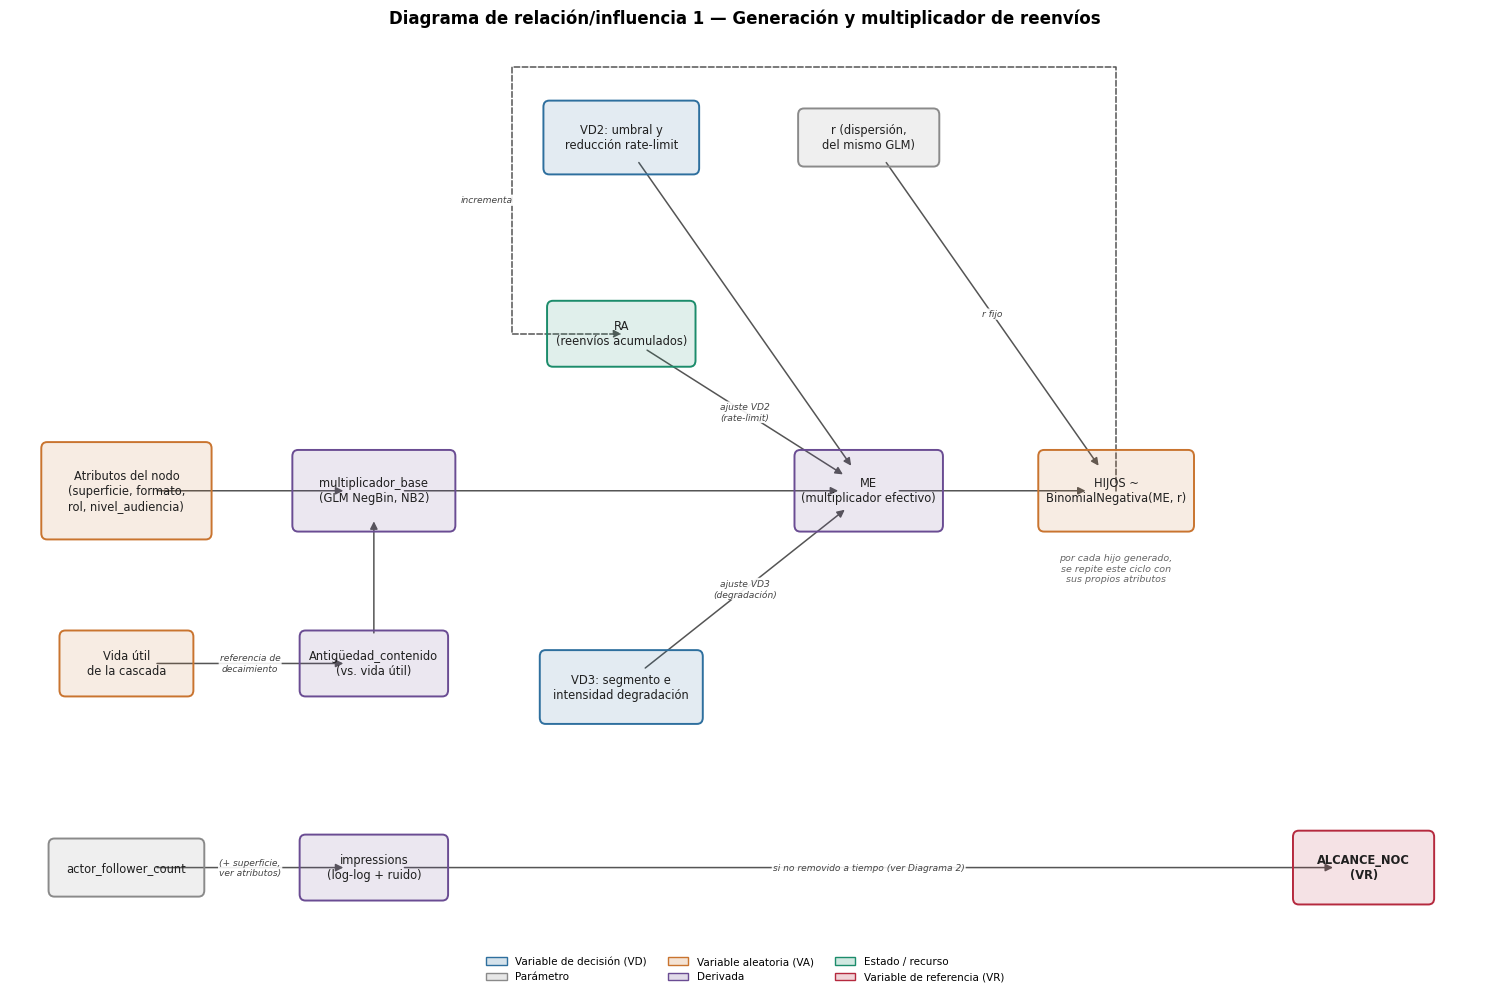

Guardado: ../figuras/fig_anexo_diagrama_relacion_1.png


In [2]:
nodes_a = [
    {'id': 'atributos',   'label': 'Atributos del nodo\n(superficie, formato,\nrol, nivel_audiencia)', 'tipo': 'VA', 'x': 0, 'y': 2.5, 'w': 2.3, 'h': 1.2},
    {'id': 'vida_util',   'label': 'Vida útil\nde la cascada', 'tipo': 'VA', 'x': 0, 'y': 0.3, 'w': 1.8, 'h': 0.8},
    {'id': 'seguidores',  'label': 'actor_follower_count', 'tipo': 'Parametro', 'x': 0, 'y': -2.3, 'w': 2.1, 'h': 0.7},

    {'id': 'antig_cont',  'label': 'Antigüedad_contenido\n(vs. vida útil)', 'tipo': 'Derivada', 'x': 3.4, 'y': 0.3, 'w': 2.0, 'h': 0.8},
    {'id': 'mult_base',   'label': 'multiplicador_base\n(GLM NegBin, NB2)', 'tipo': 'Derivada', 'x': 3.4, 'y': 2.5, 'w': 2.2, 'h': 1.0},
    {'id': 'impressions', 'label': 'impressions\n(log-log + ruido)', 'tipo': 'Derivada', 'x': 3.4, 'y': -2.3, 'w': 2.0, 'h': 0.8},

    {'id': 'vd2',  'label': 'VD2: umbral y\nreducción rate-limit', 'tipo': 'VD', 'x': 6.8, 'y': 7.0, 'w': 2.1, 'h': 0.9},
    {'id': 'ra',   'label': 'RA\n(reenvíos acumulados)', 'tipo': 'Estado', 'x': 6.8, 'y': 4.5, 'w': 2.0, 'h': 0.8},
    {'id': 'vd3',  'label': 'VD3: segmento e\nintensidad degradación', 'tipo': 'VD', 'x': 6.8, 'y': 0.0, 'w': 2.2, 'h': 0.9},

    {'id': 'me',     'label': 'ME\n(multiplicador efectivo)', 'tipo': 'Derivada', 'x': 10.2, 'y': 2.5, 'w': 2.0, 'h': 1.0},
    {'id': 'r_glm',  'label': 'r (dispersión,\ndel mismo GLM)', 'tipo': 'Parametro', 'x': 10.2, 'y': 7.0, 'w': 1.9, 'h': 0.7},

    {'id': 'hijos', 'label': 'HIJOS ~\nBinomialNegativa(ME, r)', 'tipo': 'VA', 'x': 13.6, 'y': 2.5, 'w': 2.1, 'h': 1.0},

    {'id': 'alcance', 'label': 'ALCANCE_NOC\n(VR)', 'tipo': 'VR', 'x': 17.0, 'y': -2.3, 'w': 1.9, 'h': 0.9},
]
edges_a = [
    {'src': 'vida_util', 'dst': 'antig_cont', 'label': 'referencia de\ndecaimiento'},
    {'src': 'atributos', 'dst': 'mult_base'},
    {'src': 'antig_cont', 'dst': 'mult_base'},
    {'src': 'mult_base', 'dst': 'me'},
    {'src': 'ra', 'dst': 'me', 'label': 'ajuste VD2\n(rate-limit)'},
    {'src': 'vd2', 'dst': 'me'},
    {'src': 'vd3', 'dst': 'me', 'label': 'ajuste VD3\n(degradación)'},
    {'src': 'me', 'dst': 'hijos'},
    {'src': 'r_glm', 'dst': 'hijos', 'label': 'r fijo'},
    {'src': 'hijos', 'dst': 'ra', 'label': 'incrementa', 'style': '--',
     'wp': [(13.6, 7.9), (5.3, 7.9), (5.3, 4.5)], 'label_frac': 0.5, 'label_offset': (-0.35, 0)},
    {'src': 'seguidores', 'dst': 'impressions', 'label': '(+ superficie,\nver atributos)'},
    {'src': 'impressions', 'dst': 'alcance', 'label': 'si no removido a tiempo (ver Diagrama 2)'},
]
notes_a = [{'x': 13.6, 'y': 1.7, 'text': 'por cada hijo generado,\nse repite este ciclo con\nsus propios atributos', 'va': 'top'}]
render_diagram(nodes_a, edges_a,
    'Diagrama de relación/influencia 1 — Generación y multiplicador de reenvíos',
    '../figuras/fig_anexo_diagrama_relacion_1.png', figsize=(15, 10), notes=notes_a)


## 2. Clasificación, moderación y costos

OK: 2 variable(s) de referencia, todas sumidero (sin salida).


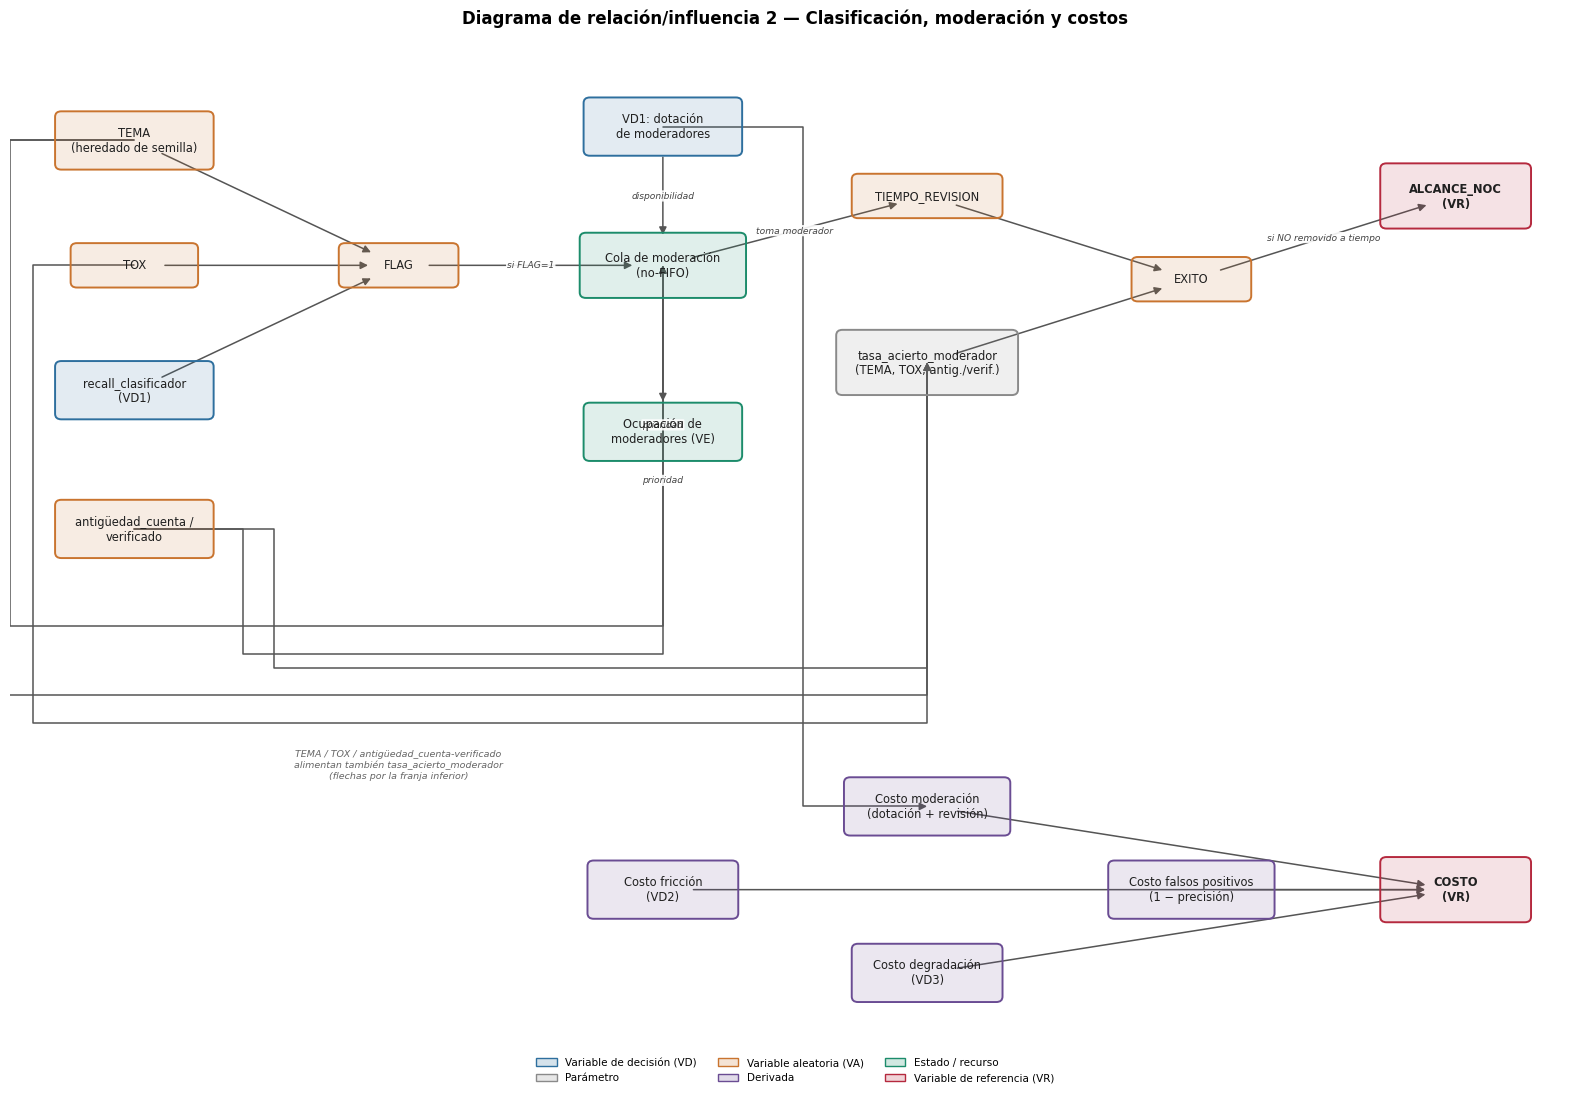

Guardado: ../figuras/fig_anexo_diagrama_relacion_2.png


In [3]:
nodes_b = [
    {'id': 'tema',  'label': 'TEMA\n(heredado de semilla)', 'tipo': 'VA', 'x': 0, 'y': 5.4, 'w': 2.0, 'h': 0.8},
    {'id': 'tox',   'label': 'TOX', 'tipo': 'VA', 'x': 0, 'y': 3.6, 'w': 1.6, 'h': 0.6},
    {'id': 'recall', 'label': 'recall_clasificador\n(VD1)', 'tipo': 'VD', 'x': 0, 'y': 1.8, 'w': 2.0, 'h': 0.8},
    {'id': 'antig_cuenta', 'label': 'antigüedad_cuenta /\nverificado', 'tipo': 'VA', 'x': 0, 'y': -0.2, 'w': 2.0, 'h': 0.8},

    {'id': 'flag', 'label': 'FLAG', 'tipo': 'VA', 'x': 3.4, 'y': 3.6, 'w': 1.5, 'h': 0.6},

    {'id': 'dotacion', 'label': 'VD1: dotación\nde moderadores', 'tipo': 'VD', 'x': 6.8, 'y': 5.6, 'w': 2.0, 'h': 0.8},
    {'id': 'cola', 'label': 'Cola de moderación\n(no-FIFO)', 'tipo': 'Estado', 'x': 6.8, 'y': 3.6, 'w': 2.1, 'h': 0.9},
    {'id': 'ocupacion', 'label': 'Ocupación de\nmoderadores (VE)', 'tipo': 'Estado', 'x': 6.8, 'y': 1.2, 'w': 2.0, 'h': 0.8},

    {'id': 'tiempo_rev', 'label': 'TIEMPO_REVISION', 'tipo': 'VA', 'x': 10.2, 'y': 4.6, 'w': 1.9, 'h': 0.6},
    {'id': 'tasa_acierto', 'label': 'tasa_acierto_moderador\n(TEMA, TOX, antig./verif.)', 'tipo': 'Parametro', 'x': 10.2, 'y': 2.2, 'w': 2.3, 'h': 0.9},

    {'id': 'exito', 'label': 'EXITO', 'tipo': 'VA', 'x': 13.6, 'y': 3.4, 'w': 1.5, 'h': 0.6},

    {'id': 'alcance', 'label': 'ALCANCE_NOC\n(VR)', 'tipo': 'VR', 'x': 17.0, 'y': 4.6, 'w': 1.9, 'h': 0.9},

    {'id': 'costo_mod',  'label': 'Costo moderación\n(dotación + revisión)', 'tipo': 'Derivada', 'x': 10.2, 'y': -4.2, 'w': 2.1, 'h': 0.8},
    {'id': 'costo_fric', 'label': 'Costo fricción\n(VD2)', 'tipo': 'Derivada', 'x': 6.8, 'y': -5.4, 'w': 1.9, 'h': 0.8},
    {'id': 'costo_degr', 'label': 'Costo degradación\n(VD3)', 'tipo': 'Derivada', 'x': 10.2, 'y': -6.6, 'w': 1.9, 'h': 0.8},
    {'id': 'costo_fp',   'label': 'Costo falsos positivos\n(1 − precisión)', 'tipo': 'Derivada', 'x': 13.6, 'y': -5.4, 'w': 2.1, 'h': 0.8},
    {'id': 'costo', 'label': 'COSTO\n(VR)', 'tipo': 'VR', 'x': 17.0, 'y': -5.4, 'w': 1.9, 'h': 0.9},
]
edges_b = [
    {'src': 'tox', 'dst': 'flag'},
    {'src': 'tema', 'dst': 'flag'},
    {'src': 'recall', 'dst': 'flag'},
    {'src': 'flag', 'dst': 'cola', 'label': 'si FLAG=1'},
    {'src': 'dotacion', 'dst': 'cola', 'label': 'disponibilidad'},
    {'src': 'cola', 'dst': 'ocupacion'},
    {'src': 'cola', 'dst': 'tiempo_rev', 'label': 'toma moderador'},
    {'src': 'tiempo_rev', 'dst': 'exito'},
    {'src': 'tasa_acierto', 'dst': 'exito'},
    {'src': 'exito', 'dst': 'alcance', 'label': 'si NO removido a tiempo'},
    {'src': 'dotacion', 'dst': 'costo_mod',
     'wp': [(8.6, 5.6), (8.6, -4.2)], 'label_frac': 1.0},
    {'src': 'costo_mod', 'dst': 'costo'},
    {'src': 'costo_fric', 'dst': 'costo'},
    {'src': 'costo_degr', 'dst': 'costo'},
    {'src': 'costo_fp', 'dst': 'costo'},
    # "prioridad de cola": TEMA / antigüedad_cuenta, ruteadas por el margen izquierdo y una
    # franja inferior despejada (y=-1.6 / -2.0) para no cruzar FLAG/cola/ocupacion
    {'src': 'tema', 'dst': 'cola', 'label': 'prioridad',
     'wp': [(-1.6, 5.4), (-1.6, -1.6), (6.8, -1.6)], 'label_frac': 2.0, 'label_offset': (0, 0.3)},
    {'src': 'antig_cuenta', 'dst': 'cola', 'label': 'prioridad',
     'wp': [(1.4, -0.2), (1.4, -2.0), (6.8, -2.0)], 'label_frac': 2.0, 'label_offset': (0, -0.3)},
    # inputs de tasa_acierto_moderador: misma franja inferior, un poco mas abajo para no
    # superponerse con las de "prioridad" de arriba
    {'src': 'tema', 'dst': 'tasa_acierto',
     'wp': [(-1.9, 5.4), (-1.9, -2.6), (10.2, -2.6)], 'label_frac': 2.0},
    {'src': 'tox', 'dst': 'tasa_acierto',
     'wp': [(-1.3, 3.6), (-1.3, -3.0), (10.2, -3.0)], 'label_frac': 2.0},
    {'src': 'antig_cuenta', 'dst': 'tasa_acierto',
     'wp': [(1.8, -0.2), (1.8, -2.2), (10.2, -2.2)], 'label_frac': 2.0},
]
notes_b = [{'x': 3.4, 'y': -3.6, 'text': 'TEMA / TOX / antigüedad_cuenta-verificado\nalimentan también tasa_acierto_moderador\n(flechas por la franja inferior)', 'va': 'center'}]
render_diagram(nodes_b, edges_b,
    'Diagrama de relación/influencia 2 — Clasificación, moderación y costos',
    '../figuras/fig_anexo_diagrama_relacion_2.png', figsize=(16, 11), notes=notes_b)
